In [ ]:
import numpy as np
import sys
from pathlib import Path

sys.path.insert(0, str(Path().absolute().parent / 'src'))

from models.graphene import BilayerGrapheneTB, SingleLayerGrapheneTB, BilayerGrapheneKP, SingleLayerGrapheneKP
from utils.kpath import make_k_path

models_dict = {
    'SLTB': SingleLayerGrapheneTB(t=2.78),
    'SLKP': SingleLayerGrapheneKP(t=2.78),
    'BLTB': BilayerGrapheneTB(t=2.78, gamma1=0.4),
    'BLKP': BilayerGrapheneKP(t=2.78, gamma1=0.4)
}

import matplotlib.pyplot as plt

class ModelValidator:
    def __init__(self, k_fixed):
        """
        初始化验证类
        :param k_fixed: 展开的高对称点坐标，例如 np.array([0.0, 0.0])
        """
        self.k_fixed = np.array(k_fixed)

    # =========================================================================
    # 需用户自行实现的接口 (User Interfaces)
    # =========================================================================
    def ham_tb(self, k, gear='SL'):
        """
        紧束缚模型哈密顿量
        :param k: 1D 数组 [kx, ky]
        :param gear: 模型类型
        :return: N x N 的复数矩阵 (Hermitian)
        """
        return models_dict[gear + 'TB'].hamiltonian(k)

    def ham_kp(self, k, gear='SL'):
        """
        k.p 模型哈密顿量 (输入 k 在模型内已经包括相对于高对称点的偏移量 q = k - k_fixed)
        :param k: 1D 数组 [kx, ky]
        :param gear: 模型类型
        :return: N x N 的复数矩阵
        """
        return models_dict[gear + 'KP'].hamiltonian(k)

    # =========================================================================
    # 核心计算与绘图逻辑
    # =========================================================================
    def solve_band(self, model_func, k_points, gear='SL'):
        """通用能带求解器"""
        bands = []
        for k in k_points:
            H = model_func(k, gear=gear)
            eigvals = np.linalg.eigvalsh(H)
            bands.append(eigvals)
        return np.array(bands)

    def plot_1d_comparison(self, direction=np.array([1.0, 0.0]), k_range=1.0, num_pts=200, gear='SL'):
        """
        沿某一方向穿过高对称点的 1D 能带对比曲线
        """
        # 生成相对于 k_fixed 的偏移量 q
        q_steps = np.linspace(-k_range, k_range, num_pts)
        q_list = [q * direction for q in q_steps]
        k_list = [self.k_fixed + q for q in q_list]

        # 求解能带
        bands_tb = self.solve_band(self.ham_tb, k_list, gear=gear)
        # k.p 输入的是相对于高对称点的 q
        bands_kp = self.solve_band(self.ham_kp, k_list, gear=gear)

        # 绘图
        plt.figure(figsize=(8, 6))
        num_bands = bands_tb.shape[1]
        
        for i in range(num_bands):
            tb_line, = plt.plot(q_steps, bands_tb[:, i], 'b-', lw=2, label='Tight-Binding' if i==0 else "")
            kp_line, = plt.plot(q_steps, bands_kp[:, i], 'r--', lw=2, label='k.p model' if i==0 else "")

        plt.axvline(x=0, color='gray', linestyle=':', alpha=0.7)
        plt.title(f'1D Band Comparison around High-Symmetry Point {self.k_fixed}')
        plt.xlabel(r'$q = k - k_0$')
        plt.ylabel('Energy (eV)')
        plt.legend(loc='best')
        plt.grid(True, alpha=0.3)
        plt.show()

    def plot_2d_surface(self, q_max=0.5, num_pts=50, gear='SL'):
        """
        高对称点附近的 2D 能量表面对比 (以第一导带和第一价带为例)
        """
        qx = np.linspace(-q_max, q_max, num_pts)
        qy = np.linspace(-q_max, q_max, num_pts)
        QX, QY = np.meshgrid(qx, qy)
        
        # 仅展示最靠近费米面的两根能带（假设矩阵大小 >= 2）
        # 这里动态获取中间两根能带的索引
        test_H = self.ham_tb(self.k_fixed, gear=gear)
        n_bel = test_H.shape[0] // 2
        idx_v, idx_c = n_bel - 1, n_bel # 价带顶和导带底

        E_tb_c, E_tb_v = np.zeros_like(QX), np.zeros_like(QY)
        E_kp_c, E_kp_v = np.zeros_like(QX), np.zeros_like(QY)

        for i in range(num_pts):
            for j in range(num_pts):
                q = np.array([QX[i, j], QY[i, j]])
                k = self.k_fixed + q
                
                eig_tb = np.linalg.eigvalsh(self.ham_tb(k, gear=gear))
                eig_kp = np.linalg.eigvalsh(self.ham_kp(k, gear=gear))
                
                E_tb_v[i, j], E_tb_c[i, j] = eig_tb[idx_v], eig_tb[idx_c]
                E_kp_v[i, j], E_kp_c[i, j] = eig_kp[idx_v], eig_kp[idx_c]

        # 3D 绘图
        fig = plt.figure(figsize=(14, 6))
        
        # TB 表面
        ax1 = fig.add_subplot(121, projection='3d')
        ax1.plot_surface(QX, QY, E_tb_c, cmap='Blues', alpha=0.7, label='TB Conduction')
        ax1.plot_surface(QX, QY, E_tb_v, cmap='Blues', alpha=0.5, label='TB Valence')
        ax1.set_title("Tight-Binding Surface")
        ax1.set_xlabel(r'$q_x$')
        ax1.set_ylabel(r'$q_y$')

        # k.p 表面
        ax2 = fig.add_subplot(122, projection='3d')
        ax2.plot_surface(QX, QY, E_kp_c, cmap='Reds', alpha=0.7, label='k.p Conduction')
        ax2.plot_surface(QX, QY, E_kp_v, cmap='Reds', alpha=0.5, label='k.p Valence')
        ax2.set_title(r"$\mathbf{k}\cdot\mathbf{p}$ Model Surface")
        ax2.set_xlabel(r'$q_x$')
        ax2.set_ylabel(r'$q_y$')

        plt.show()

# =========================================================================
# 运行示例
# =========================================================================


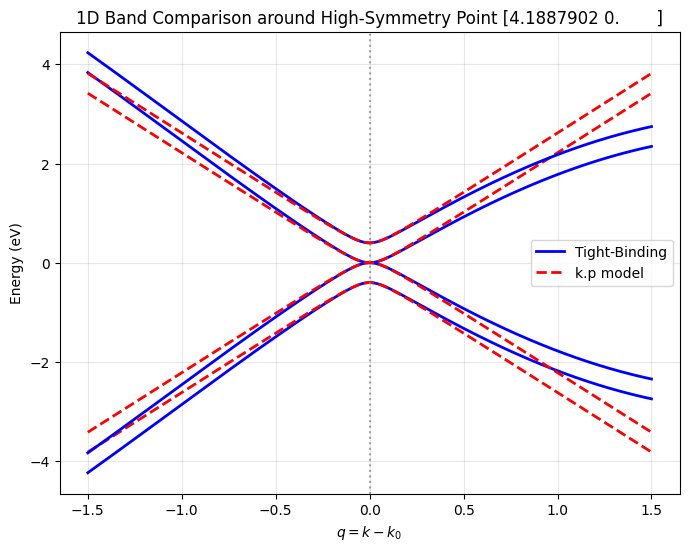

In [ ]:
gear = 'BL'  # 'SL' 或 'BL'，选择单层或双层模型
k_fixed = models_dict[gear + 'TB'].high_symmetry_points()["K"]

# 假设我们在 K 点  附近做对比
validator = ModelValidator(k_fixed=k_fixed)

# 1. 对比沿 kx 方向的 1D 能带 (并在远处观察 k.p 的发散行为)
# 观察在多大的动量范围内，低能有效模型还能保持足够高的精度。
# k_range 设置得大一点（如 1.5），可以看到解析展开在远处的失真
validator.plot_1d_comparison(direction=np.array([1.0, 0.0]), k_range=1.5, num_pts=300, gear=gear)


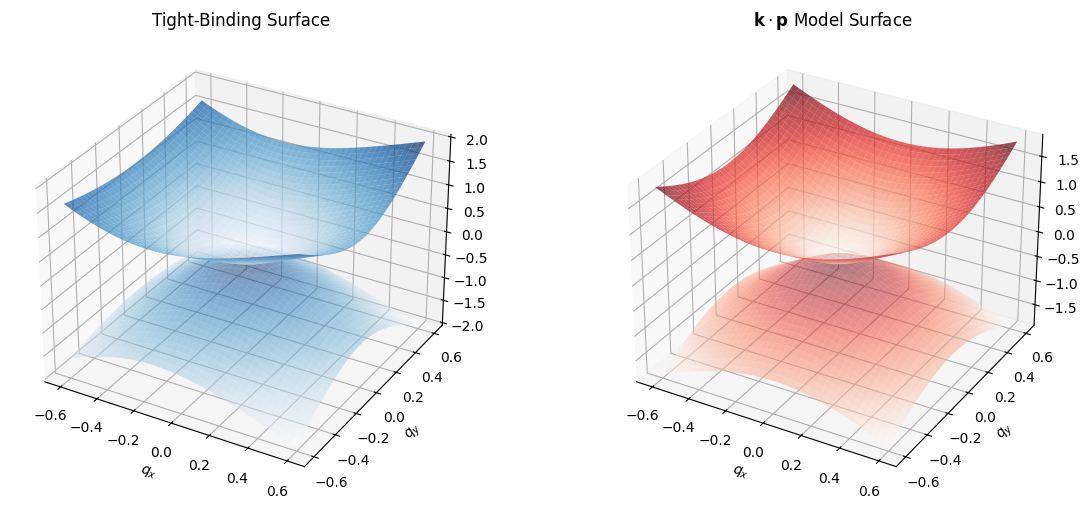

In [13]:

# 2. 对比高对称点邻域内的 2D 能量表面 (q_max 较小，专注于低能有效性)
validator.plot_2d_surface(q_max=0.6, num_pts=40, gear=gear)